# Fellegi-Sunter Baseline — Manual Validation Notebook

**Purpose.** Pull 5 random record pairs from each predicted tier (`auto_merge`, `human_review`, `no_match`) produced by `fs_splink_baseline` and manually inspect the match probability against the underlying records.

**Where this runs.** This notebook is authored off-VM but **executes only on the VM** against real `MDM_Population` data. Inputs are auto-resolved to the highest-versioned cleaned parquet + candidate-pairs parquet on disk (same convention as `run_real_baseline.py`).

**Output / artifact.** After **Run All**, the reviewer fills in the *Reviewer judgments* section at the bottom of this notebook (per-pair verdict + notes), saves, commits, pushes. **The committed notebook is the written validation record.**

**PHI note.** Output cells will contain identifier values (names, DOB, SSN, addresses). They stay on the VM. If you commit this notebook with outputs, you are committing PHI to the repo — decide deliberately whether to `Cell → All Output → Clear` before committing.

## 1. Setup & imports

In [1]:
from __future__ import annotations

import re
import sys
from datetime import datetime
from pathlib import Path

# Project root = two levels up from notebooks/fellegi_sunter/.
PROJECT_ROOT = Path.cwd().resolve().parents[1]
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import pandas as pd

from models.experiments.fs_splink_baseline import fellegi_sunter_baseline as fs
from src.features.blocking import COL_PATID

pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 120)
pd.set_option("display.width", 200)

print(f"PROJECT_ROOT = {PROJECT_ROOT}")

PROJECT_ROOT = C:\Users\SachinPatel\Desktop\UofC-EMPI


In [2]:
# Notebook-local constants. Override here if you want a different sample size,
# seed, or to point at alternate input directories.
RANDOM_SEED = 42
SAMPLES_PER_TIER = 5
U_MAX_PAIRS = 1e6  # Matches run_real_baseline.py production default.

PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
BLOCKING_DIR = PROJECT_ROOT / "src" / "features" / "outputs" / "blocking"

TIERS = ["auto_merge", "human_review", "no_match"]

## 2. Auto-resolve highest-versioned inputs

Mirrors the version-resolution convention of `src/data/clean.py` and `src/features/run_blocking.py`: parse the integer `v<N>` token from each filename and pick the maximum.

In [3]:
_VERSION_RE = re.compile(r"_v(\d+)_")


def _latest_versioned(dir_: Path, pattern: str) -> Path:
    """Return the path in `dir_` matching `pattern` with the highest _v<N>_ token."""
    candidates = []
    for p in dir_.glob(pattern):
        m = _VERSION_RE.search(p.name)
        if m:
            candidates.append((int(m.group(1)), p))
    if not candidates:
        raise FileNotFoundError(
            f"No files matching {pattern!r} in {dir_}. "
            "Confirm the cleaning/blocking pipelines have been run on the VM."
        )
    candidates.sort(key=lambda t: t[0])
    return candidates[-1][1]


cleaned_path = _latest_versioned(PROCESSED_DIR, "MDM_Population_cleaned_v*_*.parquet")
pairs_path = _latest_versioned(BLOCKING_DIR, "candidate_pairs_v*_*.parquet")

print(f"Cleaned parquet : {cleaned_path.relative_to(PROJECT_ROOT)}")
print(f"Candidate pairs : {pairs_path.relative_to(PROJECT_ROOT)}")

Cleaned parquet : data\processed\MDM_Population_cleaned_v3_2026_06_11.parquet
Candidate pairs : src\features\outputs\blocking\candidate_pairs_v4_2026_06_11.parquet


## 3. Score with `full_output=True`

`full_output=True` returns the classified frame *before* projection to the 5-col evaluation schema, retaining `match_probability`, `match_weight`, `classification_tier`, `source_blocks`, `n_blocks`, and Splink's `gamma_*` per-field agreement levels for downstream inspection.

Training is the slow step (single call to `run_fs_baseline`).

In [4]:
df_clean = pd.read_parquet(cleaned_path)
print(f"Loaded {len(df_clean):,} cleaned records.")

Loaded 163,364 cleaned records.


In [5]:
df_scored = fs.run_fs_baseline(
    str(pairs_path),
    df_clean,
    u_max_pairs=U_MAX_PAIRS,
    full_output=True,
)

print(f"Scored {len(df_scored):,} candidate pairs.")
print("Tier breakdown:")
print(df_scored["classification_tier"].value_counts().reindex(TIERS, fill_value=0))

SETTINGS VALIDATION: Errors were identified in your settings dictionary. 

Invalid Columns(s) in Blocking Rule(s)

    SQL: `
EXISTS (
    SELECT 1 FROM candidate_pairs cp
    WHERE cp.PATID_A = l.PATID AND cp.PATID_B = r.PATID
)
`
       - Invalid table names provided (only `l.` and `r.` are valid): `cp.PATID_A`, `cp.PATID_B`

You may want to verify your settings dictionary has valid inputs in all fields before continuing.
You are using the default value for `max_pairs`, which may be too small and thus lead to inaccurate estimates for your model's u-parameters. Consider increasing to 1e8 or 1e9, which will result in more accurate estimates, but with a longer run time.
----- Estimating u probabilities using random sampling -----
u probability not trained for SSN - Exact match on SSN_clean (comparison vector value: 2). This usually means the comparison level was never observed in the training data.
u probability not trained for Email_clean - Exact match on Email_clean (comparison vector

Scored 205,424 candidate pairs.
Tier breakdown:
classification_tier
auto_merge       66454
human_review      1369
no_match        137601
Name: count, dtype: int64


## 4. Stratified random sample (5 per tier, fixed seed)

Deterministic across runs given `RANDOM_SEED = 42`. If a tier has fewer than `SAMPLES_PER_TIER` pairs, the notebook takes what's available and prints a warning rather than erroring.

In [6]:
sampled_chunks = []
for tier in TIERS:
    tier_df = df_scored[df_scored["classification_tier"] == tier]
    n_available = len(tier_df)
    n_take = min(SAMPLES_PER_TIER, n_available)
    if n_take < SAMPLES_PER_TIER:
        print(
            f"WARN: tier {tier!r} has only {n_available} pairs; sampling {n_take}."
        )
    sampled_chunks.append(tier_df.sample(n=n_take, random_state=RANDOM_SEED))

sampled = pd.concat(sampled_chunks).reset_index(drop=True)
print(f"Sampled {len(sampled)} pairs total.")
print(sampled["classification_tier"].value_counts().reindex(TIERS, fill_value=0))

Sampled 15 pairs total.
classification_tier
auto_merge      5
human_review    5
no_match        5
Name: count, dtype: int64


## 5. Side-by-side identifier display

For each sampled pair the notebook renders:

1. A one-line header with `classification_tier`, `match_probability`, `match_weight`, and which blocks fired.
2. A two-column DataFrame (`Record A` vs `Record B`) of the cleaned identifier fields. Values are pulled from the cleaned dataframe by `PATID` — this avoids depending on Splink's `_l/_r` suffix convention and shows all fields whether or not the model used them as evidence.
3. A compact view of Splink's `gamma_*` per-field agreement levels (when present), so you can see *why* the model assigned the score it did.

In [7]:
# Fields to display per record, in order. (Label, cleaned-dataframe column name.)
DISPLAY_FIELDS: list[tuple[str, str]] = [
    ("PATID",              "PATID"),
    ("First name",         "FirstNM_clean"),
    ("Middle name",        "MiddleNM_clean"),
    ("Last name",          "LastNM_clean"),
    ("Full name tokens",   "full_name_tokens"),
    ("DOB",                "BirthDT_clean"),
    ("SSN (full)",         "SSN_clean"),
    ("SSN last-4",         "last_4_SSN"),
    ("Email",              "Email_clean"),
    ("Address line 1",     "AddressLine1_clean"),
    ("Address line 2",     "AddressLine2_clean"),
    ("City",               "CityNM_clean"),
    ("State",              "StateCD_clean"),
    ("ZIP",                "ZipCD_clean_base"),
    ("Phones (set)",       "Phones_set"),
]

# Index df_clean by PATID once for O(1) lookups.
_clean_indexed = df_clean.set_index(COL_PATID, drop=False)


def _lookup(patid: str) -> pd.Series:
    """Pull one cleaned record by PATID; returns an empty Series if absent."""
    try:
        return _clean_indexed.loc[patid]
    except KeyError:
        return pd.Series(dtype=object)


def render_identifier_table(patid_a: str, patid_b: str) -> pd.DataFrame:
    """Two-column side-by-side DataFrame of cleaned identifier fields."""
    rec_a = _lookup(patid_a)
    rec_b = _lookup(patid_b)
    rows = {}
    for label, col in DISPLAY_FIELDS:
        if col not in df_clean.columns:
            continue  # field absent in this cleaned parquet version; skip.
        rows[label] = [rec_a.get(col, np.nan), rec_b.get(col, np.nan)]
    return pd.DataFrame.from_dict(
        rows, orient="index", columns=["Record A", "Record B"]
    )


def render_gamma_table(row: pd.Series) -> pd.DataFrame | None:
    """Splink's gamma_<field> per-field agreement levels, if retained."""
    gamma_cols = [c for c in row.index if c.startswith("gamma_")]
    if not gamma_cols:
        return None
    out = pd.DataFrame(
        {"agreement_level": [row[c] for c in gamma_cols]},
        index=[c.removeprefix("gamma_") for c in gamma_cols],
    )
    out.index.name = "comparison"
    return out

In [ ]:
from IPython.display import display, Markdown

for i, row in sampled.iterrows():
    pair_num = i + 1
    patid_a = row["PATID_A"]
    patid_b = row["PATID_B"]
    tier = row["classification_tier"]
    p = row.get("match_probability", float("nan"))
    w = row.get("match_weight", float("nan"))
    src_blocks = row.get("source_blocks", "")
    n_blocks = row.get("n_blocks", "")

    display(Markdown(
        f"### Pair {pair_num}/{len(sampled)} \u2014 tier=`{tier}`  \n"
        f"`PATID_A={patid_a}` \u2194 `PATID_B={patid_b}`  \n"
        f"`match_probability={p:.4f}`  \u00b7  `match_weight={w:.3f}`  "
        f"\u00b7  `n_blocks={n_blocks}`  \u00b7  `source_blocks={src_blocks}`"
    ))
    display(render_identifier_table(patid_a, patid_b))
    gammas = render_gamma_table(row)
    if gammas is not None:
        display(Markdown("**Splink agreement levels (`gamma_*`):**"))
        display(gammas)

## 6. Reviewer judgment templates

Run the cell below to generate one markdown template per sampled pair. Copy the printed block into the **Reviewer judgments** markdown cell at the bottom of this notebook and fill in `Reviewer verdict` (`true_match` / `not_match` / `unsure`) and `Reviewer notes` for each pair. Save, commit, push.

Why a printed block (not interactive widgets): markdown survives `nbconvert`, diffs cleanly in git, and the committed notebook is then a self-contained validation record.

In [ ]:
template_lines = []
for i, row in sampled.iterrows():
    pair_num = i + 1
    template_lines.append(
        f"### Pair {pair_num}/{len(sampled)} \u2014 "
        f"PATID_A={row['PATID_A']}, PATID_B={row['PATID_B']}\n"
        f"\n"
        f"- **Predicted tier:** `{row['classification_tier']}`\n"
        f"- **Model match_probability:** {row.get('match_probability', float('nan')):.4f}\n"
        f"- **Reviewer verdict:** [ true_match | not_match | unsure ]\n"
        f"- **Reviewer notes:**\n"
        f"  - \n"
    )

print("\n".join(template_lines))

## 7. Diagnostic summary (non-PHI)

Provenance trail recording which dataset version was validated. Safe to commit even when output cells are cleared.

In [10]:
tier_counts = df_scored["classification_tier"].value_counts().reindex(TIERS, fill_value=0)
total = int(tier_counts.sum())

print(f"Executed at         : {datetime.now().isoformat(timespec='seconds')}")
print(f"Cleaned parquet     : {cleaned_path.relative_to(PROJECT_ROOT)}")
print(f"Candidate pairs     : {pairs_path.relative_to(PROJECT_ROOT)}")
print(f"Cleaned records     : {len(df_clean):,}")
print(f"Candidate pairs     : {len(df_scored):,}")
print(f"Random seed         : {RANDOM_SEED}")
print(f"Samples per tier    : {SAMPLES_PER_TIER}")
print()
print("Tier distribution (full population):")
for tier in TIERS:
    n = int(tier_counts[tier])
    pct = (n / total * 100) if total else 0.0
    print(f"  {tier:<14s} {n:>10,}  ({pct:5.2f}%)")

Executed at         : 2026-06-15T09:56:17
Cleaned parquet     : data\processed\MDM_Population_cleaned_v3_2026_06_11.parquet
Candidate pairs     : src\features\outputs\blocking\candidate_pairs_v4_2026_06_11.parquet
Cleaned records     : 163,364
Candidate pairs     : 205,424
Random seed         : 42
Samples per tier    : 5

Tier distribution (full population):
  auto_merge         66,454  (32.35%)
  human_review        1,369  ( 0.67%)
  no_match          137,601  (66.98%)


## 8. Visual summaries

Population-level views of the baseline's output. All three figures share one palette and styling so they can drop directly into a presentation deck. PNGs are saved to `notebooks/fellegi_sunter/figures/` (gitignored) and filename-versioned by the resolved cleaned-parquet tag so figures don't overwrite across data refreshes.

**Why log scale on the histogram.** Real eMPI score distributions are bimodal: most candidate pairs collapse to ~0 (clear non-matches) or ~1 (clear matches), with a small `human_review` middle band. On a linear y-axis that middle band is visually invisible at production pair counts. Log scale keeps every tier legible without distorting the bimodal shape.

In [11]:
import re as _re
import matplotlib.pyplot as plt

# ---- Presentation-grade styling (applies to all three figures) -------------
plt.rcParams.update({
    "figure.facecolor":   "white",
    "axes.facecolor":     "white",
    "font.family":        "sans-serif",
    "font.size":          11,
    "axes.titlesize":     13,
    "axes.titleweight":   "bold",
    "axes.labelsize":     11,
    "axes.labelcolor":    "#333333",
    "axes.edgecolor":     "#555555",
    "axes.spines.top":    False,
    "axes.spines.right":  False,
    "axes.grid":          True,
    "grid.color":         "#DDDDDD",
    "grid.linewidth":     0.6,
    "grid.alpha":         0.8,
    "xtick.color":        "#333333",
    "ytick.color":        "#333333",
    "legend.frameon":     False,
    "savefig.dpi":        200,
    "savefig.bbox":       "tight",
    "savefig.facecolor":  "white",
})

# Shared palette — aligned with the reference strip chart.
TIER_COLORS = {
    "no_match":     "#B5B5B5",  # neutral gray
    "human_review": "#F0BE7E",  # warm peach
    "auto_merge":   "#88B888",  # muted green
}
TIER_EDGE = {
    "no_match":     "#7F7F7F",
    "human_review": "#C68A3F",
    "auto_merge":   "#4F8A4F",
}
# Display order: low → high match_probability (matches strip chart left→right).
TIER_ORDER_LOW_TO_HIGH = ["no_match", "human_review", "auto_merge"]

# Pull thresholds from the FS module so charts auto-track any retuning.
REVIEW_FLOOR = fs.DEFAULT_REVIEW_FLOOR
AUTO_MERGE_THRESHOLD = fs.DEFAULT_AUTO_MERGE_THRESHOLD

# Output dir for PNGs (gitignored via notebooks/**/figures/).
FIGURES_DIR = Path.cwd() / "figures"
FIGURES_DIR.mkdir(exist_ok=True)

# Version tag pulled from the resolved cleaned parquet so PNG filenames track
# the dataset version they were generated from.
_version_match = _re.search(r"(v\d+_\d{4}_\d{2}_\d{2})", cleaned_path.name)
VERSION_TAG = _version_match.group(1) if _version_match else "unversioned"

# Pre-compute reusable stats.
_scores = df_scored["match_probability"].to_numpy()
_total = int(len(df_scored))
_tier_counts = df_scored["classification_tier"].value_counts().reindex(
    TIER_ORDER_LOW_TO_HIGH, fill_value=0
).astype(int)
_tier_pct = (_tier_counts / _total * 100) if _total else _tier_counts * 0.0
_five_num = {
    "min":    float(np.min(_scores)),
    "p25":    float(np.quantile(_scores, 0.25)),
    "median": float(np.median(_scores)),
    "p75":    float(np.quantile(_scores, 0.75)),
    "max":    float(np.max(_scores)),
}

print(f"Figures will save to : {FIGURES_DIR.relative_to(PROJECT_ROOT)}")
print(f"Version tag          : {VERSION_TAG}")


Figures will save to : notebooks\fellegi_sunter\figures
Version tag          : v3_2026_06_11


### 8.1 Predicted tier breakdown

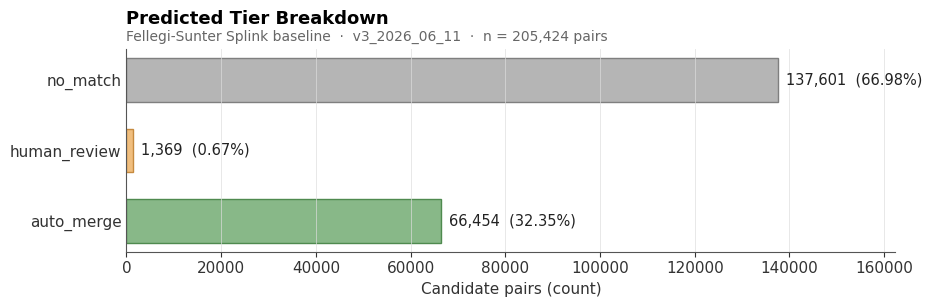

Saved → notebooks\fellegi_sunter\figures\tier_breakdown__v3_2026_06_11.png

Tier counts:
  no_match          137,601  (66.98%)
  human_review        1,369  ( 0.67%)
  auto_merge         66,454  (32.35%)


In [12]:
fig, ax = plt.subplots(figsize=(9.5, 3.2))

y_pos = np.arange(len(TIER_ORDER_LOW_TO_HIGH))
counts = _tier_counts.values
colors = [TIER_COLORS[t] for t in TIER_ORDER_LOW_TO_HIGH]
edges = [TIER_EDGE[t] for t in TIER_ORDER_LOW_TO_HIGH]

bars = ax.barh(y_pos, counts, color=colors, edgecolor=edges, linewidth=1.0, height=0.62)

# Annotate each bar with count + pct, placed just outside the bar end.
_max_count = int(max(counts)) if len(counts) else 0
x_pad = _max_count * 0.012 if _max_count > 0 else 0.5
for bar, tier in zip(bars, TIER_ORDER_LOW_TO_HIGH):
    n = int(_tier_counts[tier])
    pct = float(_tier_pct[tier])
    ax.text(
        bar.get_width() + x_pad,
        bar.get_y() + bar.get_height() / 2,
        f"{n:,}  ({pct:.2f}%)",
        va="center", ha="left", fontsize=10.5, color="#222222",
    )

ax.set_yticks(y_pos)
ax.set_yticklabels(TIER_ORDER_LOW_TO_HIGH, fontsize=11)
ax.invert_yaxis()  # auto_merge on top (top-down reading: highest probability tier first)
ax.set_xlabel("Candidate pairs (count)")
ax.set_xlim(0, _max_count * 1.18 if _max_count > 0 else 1)
ax.grid(axis="y", visible=False)
ax.tick_params(axis="y", length=0)

ax.set_title("Predicted Tier Breakdown", loc="left", pad=18)
ax.text(
    0.0, 1.04,
    f"Fellegi-Sunter Splink baseline  ·  {VERSION_TAG}  ·  n = {_total:,} pairs",
    transform=ax.transAxes, fontsize=10, color="#666666",
)

fig.tight_layout()
out_path = FIGURES_DIR / f"tier_breakdown__{VERSION_TAG}.png"
fig.savefig(out_path)
plt.show()
print(f"Saved → {out_path.relative_to(PROJECT_ROOT)}")
print()
print("Tier counts:")
for tier in TIER_ORDER_LOW_TO_HIGH:
    print(f"  {tier:<14s} {int(_tier_counts[tier]):>10,}  ({float(_tier_pct[tier]):5.2f}%)")


### 8.2 Score distribution — five-number summary vs. classification thresholds

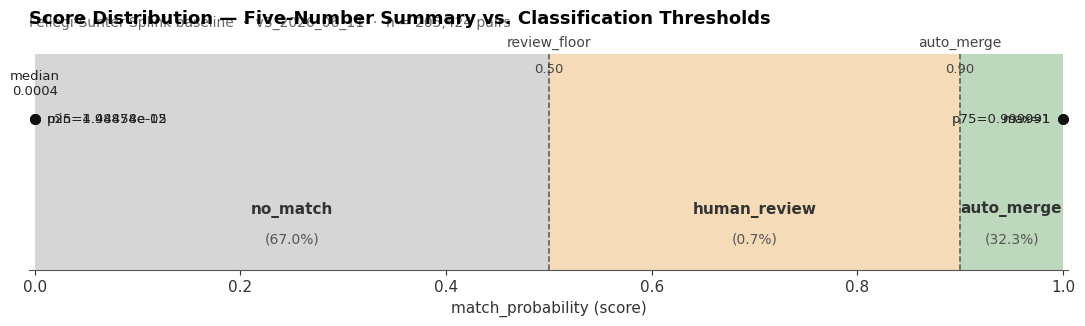

Saved → notebooks\fellegi_sunter\figures\score_distribution_strip__v3_2026_06_11.png

Five-number summary of match_probability:
  min    0.000000
  p25    0.000044
  median 0.000419
  p75    0.999991
  max    1.000000


In [13]:
fig, ax = plt.subplots(figsize=(11, 3.4))

# ---- Threshold bands (background) -----------------------------------------
ax.axvspan(0.0, REVIEW_FLOOR, color=TIER_COLORS["no_match"], alpha=0.55, lw=0)
ax.axvspan(REVIEW_FLOOR, AUTO_MERGE_THRESHOLD, color=TIER_COLORS["human_review"], alpha=0.55, lw=0)
ax.axvspan(AUTO_MERGE_THRESHOLD, 1.0, color=TIER_COLORS["auto_merge"], alpha=0.55, lw=0)

# ---- Threshold lines + top labels -----------------------------------------
for x, label in [(REVIEW_FLOOR, "review_floor"), (AUTO_MERGE_THRESHOLD, "auto_merge")]:
    ax.axvline(x, color="#555555", linestyle="--", linewidth=1.1)
    ax.text(x, 1.02, label, transform=ax.get_xaxis_transform(),
            ha="center", va="bottom", fontsize=10, color="#444444")
    ax.text(x, 0.96, f"{x:.2f}", transform=ax.get_xaxis_transform(),
            ha="center", va="top", fontsize=9.5, color="#444444")

# ---- Tier % labels centered inside each band ------------------------------
band_centers = [
    ("no_match",     REVIEW_FLOOR / 2),
    ("human_review", (REVIEW_FLOOR + AUTO_MERGE_THRESHOLD) / 2),
    ("auto_merge",   (AUTO_MERGE_THRESHOLD + 1.0) / 2),
]
for tier, x_center in band_centers:
    ax.text(x_center, 0.28, tier, ha="center", va="center",
            fontsize=11, fontweight="semibold", color="#333333")
    ax.text(x_center, 0.14, f"({float(_tier_pct[tier]):.1f}%)",
            ha="center", va="center", fontsize=10, color="#555555")

# ---- Five-number summary dots + labels ------------------------------------
# Upper track keeps dots clear of band labels below.
dot_y = 0.70

# Handle the common case where min==p25 (both 0) or max==p75 (both 1) by
# stacking the two collided labels vertically so they don't overprint.
_left_collide = abs(_five_num["min"] - _five_num["p25"]) < 1e-6
_right_collide = abs(_five_num["max"] - _five_num["p75"]) < 1e-6

ax.scatter([_five_num["min"]], [dot_y], s=46, color="#111111", zorder=5)
if _left_collide:
    ax.text(_five_num["min"] + 0.012, dot_y + 0.08,
            f"min={_five_num['min']:g}", ha="left", va="bottom",
            fontsize=9.5, color="#222222")
    ax.text(_five_num["p25"] + 0.012, dot_y - 0.08,
            f"p25={_five_num['p25']:g}", ha="left", va="top",
            fontsize=9.5, color="#222222")
else:
    ax.text(_five_num["min"] + 0.012, dot_y,
            f"min={_five_num['min']:g}", ha="left", va="center",
            fontsize=9.5, color="#222222")
    ax.scatter([_five_num["p25"]], [dot_y], s=46, color="#111111", zorder=5)
    ax.text(_five_num["p25"] + 0.012, dot_y,
            f"p25={_five_num['p25']:g}", ha="left", va="center",
            fontsize=9.5, color="#222222")

# Median (always its own dot; label above to avoid the dot itself).
ax.scatter([_five_num["median"]], [dot_y], s=46, color="#111111", zorder=5)
ax.text(_five_num["median"], dot_y + 0.10,
        f"median\n{_five_num['median']:.4f}",
        ha="center", va="bottom", fontsize=9.5, color="#222222")

ax.scatter([_five_num["max"]], [dot_y], s=46, color="#111111", zorder=5)
if _right_collide:
    ax.text(_five_num["max"] - 0.012, dot_y + 0.08,
            f"max={_five_num['max']:g}", ha="right", va="bottom",
            fontsize=9.5, color="#222222")
    ax.text(_five_num["p75"] - 0.012, dot_y - 0.08,
            f"p75={_five_num['p75']:g}", ha="right", va="top",
            fontsize=9.5, color="#222222")
else:
    ax.text(_five_num["max"] - 0.012, dot_y,
            f"max={_five_num['max']:g}", ha="right", va="center",
            fontsize=9.5, color="#222222")
    ax.scatter([_five_num["p75"]], [dot_y], s=46, color="#111111", zorder=5)
    ax.text(_five_num["p75"] - 0.012, dot_y,
            f"p75={_five_num['p75']:g}", ha="right", va="center",
            fontsize=9.5, color="#222222")

# ---- Axes cosmetics -------------------------------------------------------
ax.set_xlim(-0.005, 1.005)
ax.set_ylim(0, 1)
ax.set_xlabel("match_probability (score)")
ax.set_yticks([])
ax.grid(False)
for side in ("top", "right", "left"):
    ax.spines[side].set_visible(False)

ax.set_title(
    "Score Distribution — Five-Number Summary vs. Classification Thresholds",
    loc="left", pad=22,
)
ax.text(
    0.0, 1.13,
    f"Fellegi-Sunter Splink baseline  ·  {VERSION_TAG}  ·  n = {_total:,} pairs",
    transform=ax.transAxes, fontsize=10, color="#666666",
)

fig.tight_layout()
out_path = FIGURES_DIR / f"score_distribution_strip__{VERSION_TAG}.png"
fig.savefig(out_path)
plt.show()
print(f"Saved → {out_path.relative_to(PROJECT_ROOT)}")
print()
print("Five-number summary of match_probability:")
for k, v in _five_num.items():
    print(f"  {k:<6s} {v:.6f}")


### 8.3 Score histogram — match_probability colored by tier

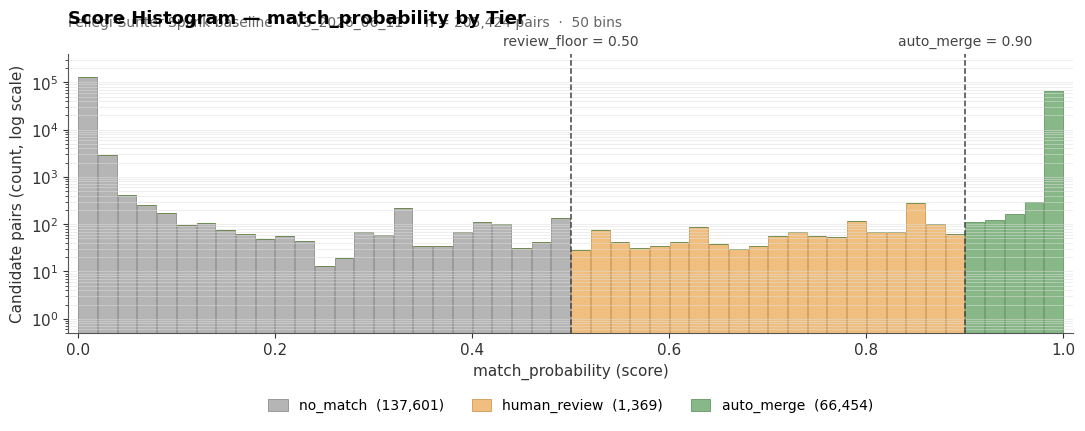

Saved → notebooks\fellegi_sunter\figures\score_histogram__v3_2026_06_11.png

Five-number summary of match_probability:
  min    0.000000
  p25    0.000044
  median 0.000419
  p75    0.999991
  max    1.000000

Per-tier counts (legend mirrors these):
  no_match          137,601  (66.98%)
  human_review        1,369  ( 0.67%)
  auto_merge         66,454  (32.35%)


In [14]:
HIST_BINS = 50

fig, ax = plt.subplots(figsize=(11, 4.6))

bin_edges = np.linspace(0.0, 1.0, HIST_BINS + 1)
bin_width = bin_edges[1] - bin_edges[0]
bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2

# Build per-tier histograms over identical bins, then stack.
tier_hists = {}
for tier in TIER_ORDER_LOW_TO_HIGH:
    scores_t = df_scored.loc[df_scored["classification_tier"] == tier, "match_probability"].to_numpy()
    h, _ = np.histogram(scores_t, bins=bin_edges)
    tier_hists[tier] = h

cumulative = np.zeros(HIST_BINS, dtype=float)
for tier in TIER_ORDER_LOW_TO_HIGH:
    h = tier_hists[tier]
    ax.bar(
        bin_centers, h, width=bin_width * 0.95,
        bottom=cumulative,
        color=TIER_COLORS[tier], edgecolor=TIER_EDGE[tier], linewidth=0.5,
        label=f"{tier}  ({int(_tier_counts[tier]):,})",
        align="center",
    )
    cumulative = cumulative + h

# Log scale with a small floor so empty bins don't visually clip.
ax.set_yscale("log")
_max_total = max(cumulative.max(), 1)
ax.set_ylim(0.5, _max_total * 3)

# Threshold lines + top labels.
for x, label in [(REVIEW_FLOOR, "review_floor"), (AUTO_MERGE_THRESHOLD, "auto_merge")]:
    ax.axvline(x, color="#444444", linestyle="--", linewidth=1.1, zorder=3)
    ax.text(x, 1.02, f"{label} = {x:.2f}", transform=ax.get_xaxis_transform(),
            ha="center", va="bottom", fontsize=10, color="#444444")

ax.set_xlim(-0.01, 1.01)
ax.set_xlabel("match_probability (score)")
ax.set_ylabel("Candidate pairs (count, log scale)")
ax.grid(axis="x", visible=False)
ax.grid(axis="y", which="both", color="#DDDDDD", linewidth=0.5, alpha=0.7)

ax.legend(
    loc="upper center", bbox_to_anchor=(0.5, -0.18), ncol=3,
    fontsize=10, handlelength=1.4, handleheight=1.0, borderpad=0.6,
)

ax.set_title("Score Histogram — match_probability by Tier", loc="left", pad=22)
ax.text(
    0.0, 1.10,
    f"Fellegi-Sunter Splink baseline  ·  {VERSION_TAG}  ·  n = {_total:,} pairs  ·  {HIST_BINS} bins",
    transform=ax.transAxes, fontsize=10, color="#666666",
)

fig.tight_layout()
out_path = FIGURES_DIR / f"score_histogram__{VERSION_TAG}.png"
fig.savefig(out_path)
plt.show()
print(f"Saved → {out_path.relative_to(PROJECT_ROOT)}")
print()
print("Five-number summary of match_probability:")
for k, v in _five_num.items():
    print(f"  {k:<6s} {v:.6f}")
print()
print("Per-tier counts (legend mirrors these):")
for tier in TIER_ORDER_LOW_TO_HIGH:
    print(f"  {tier:<14s} {int(_tier_counts[tier]):>10,}  ({float(_tier_pct[tier]):5.2f}%)")


## Reviewer judgments

_Paste the templates printed in Section 6 below this line, then fill in each `Reviewer verdict` and `Reviewer notes`._

<!-- BEGIN JUDGMENTS -->

<!-- END JUDGMENTS -->